# PHT3D Example 10

读取本案例保存的 MF6PQC 结果，并使用 `input_data/PHT3D_10_results.npy` 中的 PHT3D 参考场进行对比。

In [1]:
import sys
from pathlib import Path

sys.dont_write_bytecode = True
CASE_NAME = "ex010_PHT3D_10"
candidates = (
    candidate
    for base in (Path.cwd(), *Path.cwd().parents)
    for candidate in (base, base / "examples" / CASE_NAME)
)
CASE_DIR = next(
    (
        path.resolve()
        for path in candidates
        if path.name == CASE_NAME and (path / "modflow_model.py").is_file()
    ),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{CASE_NAME} from {Path.cwd()}")
EXAMPLES_DIR = CASE_DIR.parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))

from example_utils import load_results, read_headings, restore_archives, runtime_path, time_indices

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
restore_archives(OUTPUT_DIR)
restore_archives(SIMULATION_DIR)


In [2]:
import matplotlib.pyplot as plt
import numpy as np

case_dir = CASE_DIR

output_dir = OUTPUT_DIR
results_path = output_dir / "results.npy"
headings_path = output_dir / "results_headings.txt"
times_path = output_dir / "results_times.npy"
required = (results_path, headings_path, times_path)
missing_files = [str(path) for path in required if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "缺少本案例结果文件："
        + ", ".join(missing_files)
        + "；请先运行 examples/ex010_PHT3D_10/run.py。"
    )

NROW, NCOL = 40, 80
headings = [
    line.strip()
    for line in headings_path.read_text(encoding="utf-8-sig").splitlines()
    if line.strip()
]
results = np.load(results_path, allow_pickle=False)
times = np.load(times_path, allow_pickle=False)

field_data = {
    name: results[:, headings.index(name)].reshape(len(times), NROW, NCOL) for name in headings
}

# 修改这里可以查看其他时刻；默认查看最后一帧。
plot_time = float(times[-1])
frame_index = int(np.argmin(np.abs(times - plot_time)))
frame_time = float(times[frame_index])

SPATIAL_NAMES = (
    "Benzene",
    "Toluene",
    "Oxygen",
    "Nitrate",
    "Sulfate",
    "Methane",
    "DIC",
    "Goethite",
    "Pyrite",
    "Calcite",
    "pH",
    "Ca",
)
missing_fields = sorted(set(SPATIAL_NAMES) - set(field_data))
if missing_fields:
    raise KeyError(f"结果中缺少绘图字段：{missing_fields}")

NAPL_NAMES = tuple(
    name for name in ("Benznapl", "Tolunapl", "Ethynapl", "Xylnapl") if name in field_data
)
print(f"案例目录：{case_dir}")
print(f"结果形状：{results.shape}；时间范围：{times[0]:g}–{times[-1]:g} d")
print(f"当前绘图时刻：{frame_time:g} d")


案例目录：D:\Archives\code\mf6pqc\examples\ex010_PHT3D_10
结果形状：(51, 16, 3200)；时间范围：0–500 d
当前绘图时刻：500 d


## 2. 水平分布

色标根据本案例当前时刻的数据自动设置，便于直接观察羽流和反应区。

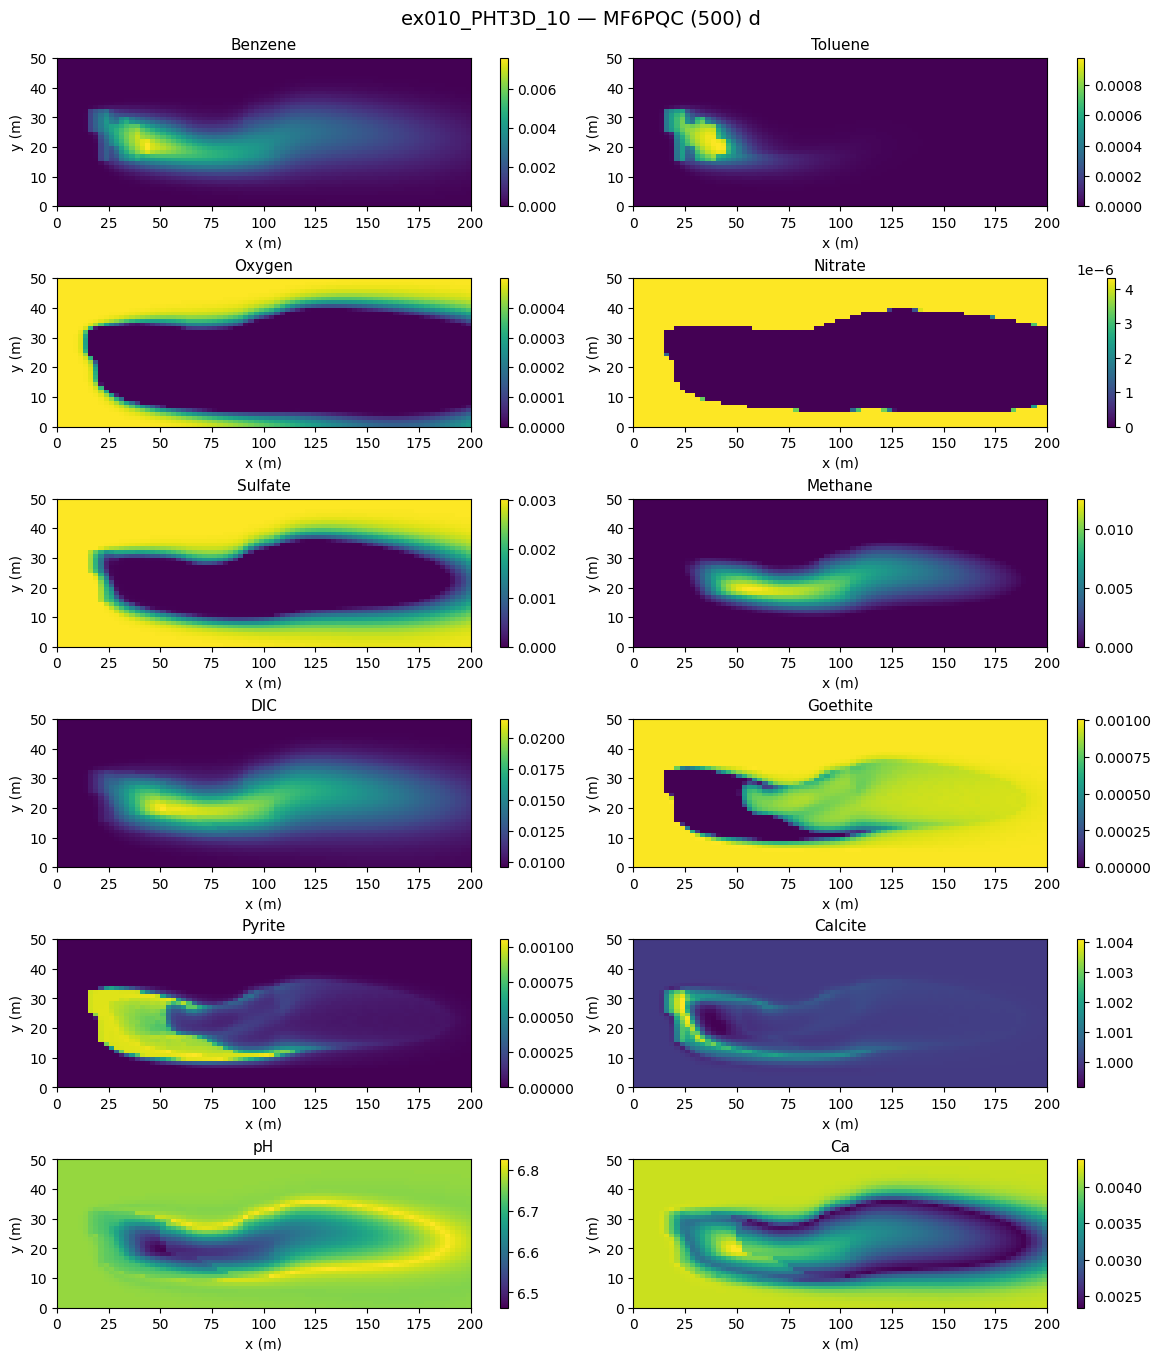

In [3]:
def color_limits(field):
    vmin = float(np.nanmin(field))
    vmax = float(np.nanmax(field))
    if np.isclose(vmin, vmax):
        delta = max(abs(vmax) * 0.01, 1.0e-12)
        vmin -= delta
        vmax += delta
    return vmin, vmax


ncols = 2
nrows = (len(SPATIAL_NAMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(11.5, 13.5), constrained_layout=True)
axes = np.asarray(axes).ravel()
extent = (0.0, 200.0, 0.0, 50.0)

for ax, name in zip(axes, SPATIAL_NAMES, strict=False):
    field = field_data[name][frame_index]
    vmin, vmax = color_limits(field)
    image = ax.imshow(
        field[::-1],
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(image, ax=ax, fraction=0.05, pad=0.04)

for ax in axes[len(SPATIAL_NAMES) :]:
    ax.set_visible(False)

fig.suptitle(f"ex010_PHT3D_10 — MF6PQC ({frame_time:g}) d", fontsize=14)
plt.show()


## 论文图 5

以下代码保持论文图的配色、字体、面板尺寸和标注，读取本案例的 `input_data/`、`output/` 与 `simulation/`。结果图保存到 `output/figures/`。

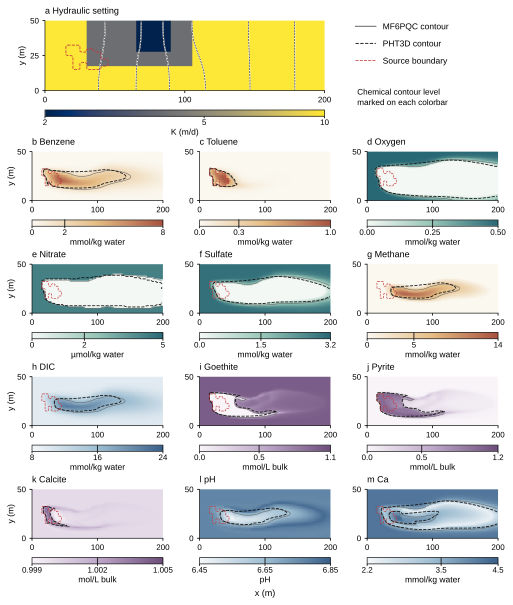

In [4]:
BASE = OUTPUT_DIR / "figures"
BASE.mkdir(exist_ok=True)

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
W = 183 / 25.4
COL = ["#477B92", "#C99659", "#986D91"]
TIME4 = ["#477B92", "#6B9B88", "#C99659", "#986D91"]

mpl.rcdefaults()
mpl.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 9,
        "axes.titlesize": 9,
        "axes.labelsize": 8.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 0.65,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "savefig.facecolor": "white",
    }
)


import flopy

raw = np.load(OUTPUT_DIR / "results.npy", allow_pickle=False)
headings = (OUTPUT_DIR / "results_headings.txt").read_text().splitlines()
times = np.load(OUTPUT_DIR / "results_times.npy")
idx = np.flatnonzero(np.isclose(times, 500)).item()
ref = np.load(INPUT_DIR / "PHT3D_10_results.npy", allow_pickle=False)
D = {k: ref[k] for k in ref.dtype.names}
D.update(x_m=(np.arange(80) + 0.5) * 2.5, y_m=50 - (np.arange(40) + 0.5) * 1.25)
D["fields"] = np.array([np.load(INPUT_DIR / "hk.npy").reshape(40, 80)])
D["source_mask"] = (np.load(INPUT_DIR / "benzene_napl.npy").reshape(40, 80) > 0) | (
    np.load(INPUT_DIR / "toluene_napl.npy").reshape(40, 80) > 0
)
D["chemical_names"] = np.array(
    [
        "Benzene",
        "Toluene",
        "Oxygen",
        "Nitrate",
        "Sulfate",
        "Methane",
        "DIC",
        "Goethite",
        "Pyrite",
        "Calcite",
        "pH",
        "Ca",
    ]
)
D["chemical_fields"] = np.stack(
    [raw[idx, headings.index(n)].reshape(40, 80) for n in D["chemical_names"]]
)
with flopy.utils.HeadFile(SIMULATION_DIR / "gwf_model.hds", precision="double") as hf:
    D["head_m"] = hf.get_data(totim=500)[0]


def _manuscript_layout_05(fig):
    fig.canvas.draw()
    width_pt, height_pt = fig.get_size_inches() * 72
    offsets = [
        (0, 0),
        (0, 0),
        (0, -13.5),
        (0, -13.5),
        (0, -13.5),
        (0, -13.5),
        (0, -13.5),
        (0, -13.5),
        (0, -12.5),
        (0, -12.5),
        (0, -12.5),
        (0, -12.5),
        (0, -12.5),
        (0, -12.5),
        (0, -11.5),
        (0, -11.5),
        (0, -11.5),
        (0, -11.5),
        (0, -11.5),
        (0, -11.5),
        (0, -10.5),
        (0, -10.5),
        (0, -10.5),
        (0, -10.5),
        (0, -10.5),
        (0, -10.5),
    ]
    if len(fig.axes) != len(offsets):
        raise ValueError("Manuscript panel count changed")
    for ax, (dx, dy) in zip(fig.axes, offsets, strict=True):
        pos = ax.get_position()
        ax.set_position([pos.x0 + dx / width_pt, pos.y0 - dy / height_pt, pos.width, pos.height])
    for legend in fig.legends:
        box = legend.get_bbox_to_anchor().transformed(fig.transFigure.inverted())
        legend.set_bbox_to_anchor(
            (box.x0 + 0 / width_pt, box.y0 - 0 / height_pt, box.width, box.height),
            transform=fig.transFigure,
        )
    for label in fig.texts:
        if label.get_text() in {"x (m)", "Distance (m)"}:
            x, y = label.get_position()
            label.set_position((x + 0 / width_pt, y - 1.5 / height_pt))


def save(n, fig, axes):
    _manuscript_layout_05(fig)
    fig.savefig(BASE / f"figure_{n:02}.png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()


def title(ax, letter, name):
    ax.set_title(f"{letter}  {name}", loc="left", pad=7, fontsize=9)


def cb(fig, ax, im, unit, ticks, offset=0.041):
    p = ax.get_position()
    ca = fig.add_axes([p.x0, p.y0 - offset, p.width, 0.010])
    c = fig.colorbar(im, cax=ca, orientation="horizontal")
    c.set_ticks(ticks)
    c.ax.xaxis.set_minor_locator(NullLocator())
    c.ax.tick_params(labelsize=8, pad=1, length=2)
    c.set_label(unit, fontsize=8.5, labelpad=2)
    return c


def fig5():
    d = D
    xc, yc = d["x_m"], d["y_m"]
    fig = plt.figure(figsize=(W, 8.7))
    a = fig.add_axes([0.105, 0.813, 0.54, 0.12])
    im = a.imshow(
        d["fields"][0],
        extent=(0, 200, 0, 50),
        origin="upper",
        aspect="equal",
        interpolation="nearest",
        cmap="cividis",
        norm=LogNorm(2, 10),
    )
    a.contour(xc, yc, d["head_m"], levels=np.arange(3.2, 5, 0.3), colors="white", linewidths=1.2)
    a.contour(
        xc,
        yc,
        d["reference_head_m"],
        levels=np.arange(3.2, 5, 0.3),
        colors="black",
        linewidths=0.55,
        linestyles="--",
    )
    a.contour(
        xc,
        yc,
        d["source_mask"].astype(float),
        levels=[0.5],
        colors="#C7363B",
        linewidths=0.8,
        linestyles="--",
    )
    a.set(xlim=(0, 200), ylim=(0, 50), xticks=[0, 100, 200], yticks=[0, 25, 50], ylabel="y (m)")
    title(a, "a", "Hydraulic setting")
    cb(fig, a, im, "K (m/d)", [2, 5, 10]).set_ticklabels(["2", "5", "10"])
    fig.legend(
        handles=[
            Line2D([], [], color=".4", lw=1, label="MF6PQC contour"),
            Line2D([], [], color=".1", ls="--", lw=0.9, label="PHT3D contour"),
            Line2D([], [], color="#C7363B", ls="--", lw=0.8, label="Source boundary"),
        ],
        loc="upper left",
        bbox_to_anchor=(0.69, 0.937),
        labelspacing=1.1,
        handlelength=2.4,
    )
    fig.text(
        0.708,
        0.794,
        "Chemical contour level\nmarked on each colorbar",
        fontsize=8.2,
        linespacing=1.5,
    )
    cmaps = {
        "warm": ["#FBF8F0", "#E5BC83", "#A7513F"],
        "teal": ["#F4F8F4", "#94C4B5", "#286774"],
        "blue": ["#F4F7FA", "#9DBDD1", "#395F89"],
        "plum": ["#F8F4F8", "#BEA8C9", "#6C4D7A"],
    }
    cmaps = {k: LinearSegmentedColormap.from_list(k, v) for k, v in cmaps.items()}

    style = {
        "Benzene": ("warm", 0, 8, 2),
        "Toluene": ("warm", 0, 1, 0.3),
        "Oxygen": ("teal", 0, 0.5, 0.25),
        "Nitrate": ("teal", 0, 5, 2),
        "Sulfate": ("teal", 0, 3.2, 1.5),
        "Methane": ("warm", 0, 14, 5),
        "DIC": ("blue", 8, 24, 16),
        "Goethite": ("plum", 0, 1.1, 0.5),
        "Pyrite": ("plum", 0, 1.2, 0.5),
        "Calcite": ("plum", 0.999, 1.005, 1.002),
        "pH": ("blue", 6.45, 6.85, 6.65),
        "Ca": ("blue", 2.2, 4.5, 3.5),
    }
    gs = fig.add_gridspec(
        4, 3, left=0.08, right=0.98, top=0.698, bottom=0.085, wspace=0.28, hspace=1.28
    )
    axs = []
    for i, name in enumerate(d["chemical_names"]):
        ax = fig.add_subplot(gs[i // 3, i % 3])
        axs.append(ax)
        scale = 1 if name in ["pH", "Calcite"] else 1e6 if name == "Nitrate" else 1000
        unit = (
            "pH"
            if name == "pH"
            else (
                "mol/L bulk"
                if name == "Calcite"
                else (
                    "µmol/kg water"
                    if name == "Nitrate"
                    else "mmol/L bulk" if name in ["Goethite", "Pyrite"] else "mmol/kg water"
                )
            )
        )
        field = d["chemical_fields"][i] * scale
        ref = d["reference_chemical_fields"][i] * scale
        pal, lo, hi, level = style[name]
        assert field.min() >= lo - 1e-10 and field.max() <= hi + 1e-10, (
            name,
            field.min(),
            field.max(),
        )
        assert field.min() < level < field.max() and ref.min() < level < ref.max()
        im = ax.imshow(
            field,
            extent=(0, 200, 0, 50),
            origin="upper",
            aspect="auto",
            interpolation="nearest",
            cmap=cmaps[pal],
            vmin=lo,
            vmax=hi,
        )
        ax.contour(xc, yc, field, levels=[level], colors=".4", linewidths=0.55)
        ax.contour(xc, yc, ref, levels=[level], colors=".08", linewidths=0.85, linestyles="--")
        ax.contour(
            xc,
            yc,
            d["source_mask"].astype(float),
            levels=[0.5],
            colors="#C7363B",
            linewidths=0.65,
            linestyles="--",
        )
        ax.set(xlim=(0, 200), ylim=(0, 50), xticks=[0, 100, 200], yticks=[0, 50])
        if i % 3 == 0:
            ax.set_ylabel("y (m)", labelpad=2)
        title(ax, chr(98 + i), str(name))
        bar = cb(fig, ax, im, unit, [lo, level, hi])
        bar.ax.axvline(level, color=".15", lw=1)
    fig.text(0.53, 0.012, "x (m)", ha="center", fontsize=9)
    save(5, fig, axs)


np.savez_compressed(BASE / "figure_05_data.npz", **D)
fig5()
